In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("/content/loan_data.csv")

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [7]:
target_col = 'loan_status'   # adjust if needed

X = df.drop(target_col, axis=1)
y = df[target_col]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

In [11]:
svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

In [12]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


=== SVM Linear ===
Accuracy: 0.8897777777777778
Precision: 0.768177028451001
Recall: 0.7253731343283583
F1 Score: 0.7461617195496417

Confusion Matrix:
[[6550  440]
 [ 552 1458]]

=== SVM RBF ===
Accuracy: 0.9077777777777778
Precision: 0.8288740245261984
Recall: 0.7398009950248756
F1 Score: 0.7818086225026288

Confusion Matrix:
[[6683  307]
 [ 523 1487]]


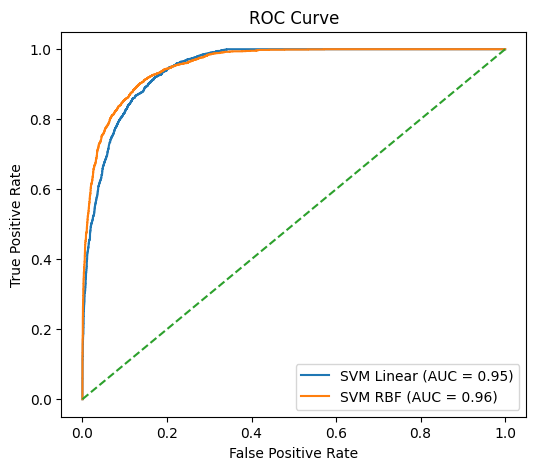

In [13]:
y_prob_linear = svm_linear.predict_proba(X_test)[:, 1]
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6,5))

evaluate_model("SVM Linear", y_test, y_pred_linear, y_prob_linear)
evaluate_model("SVM RBF", y_test, y_pred_rbf, y_prob_rbf)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_pca, y_train)

SVC()

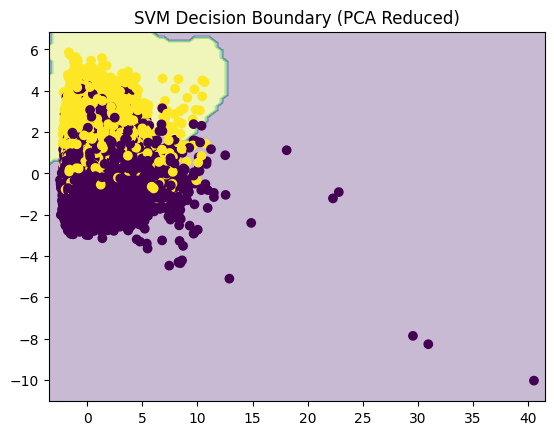

In [15]:
# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train)
plt.title("SVM Decision Boundary (PCA Reduced)")
plt.show()